# 🛒 Retailligence — Next-Week Department Sales Forecasting

**Machine Learning Fundamentals · Mini Project · Group 12** · B.Tech CSE 2024–28 · Semester V

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AnshumanAtrey/5th-sem/blob/main/Machine%20Learning/Retail%20Sales%20Prediction%20-%20Group%2012/Retailligence.ipynb)

Retailligence predicts **next week's sales for one department of one Walmart store** from the department's sales
history, the store, promotions (markdowns), the month and the holiday calendar, so a store manager can order stock
and plan staff one week ahead.

> **Run it live:** open in Colab → *Runtime → Run all* (about 3 minutes). Every chart and number in the report and in
> the Streamlit app comes from this notebook.

| # | Section |
|---|---|
| 0 | Setup (works in the repo, on Colab and on Kaggle) |
| 1 | The problem and what the brief asks for |
| 2 | Data: files and key numbers |
| 3 | Data classification |
| 4 | Data quality and cleaning decisions |
| 5 | Feature engineering: history, date/time, holidays, promotion |
| 6 | Exploratory Data Analysis |
| 7 | Train/test design: never peek at the future |
| 8 | Baselines and the two regression models |
| 9 | Cross-validation |
| 10 | Feature selection |
| 11 | Choosing the polynomial degree |
| 12 | Final test on 17 unseen weeks |
| 13 | Residuals, week-by-week error, holiday close-up |
| 14 | Which inputs matter |
| 15 | Save the model for the Streamlit app |
| 16 | Answers to the brief, limitations |

## 0 · Setup

In [1]:
# Runs in three places: inside the project folder, on Google Colab, or on Kaggle (turn Internet on).
import os, subprocess, sys
from pathlib import Path

REPO = "https://github.com/AnshumanAtrey/5th-sem.git"
PROJECT = "Machine Learning/Retail Sales Prediction - Group 12"
if not Path("src/features.py").exists():  # not inside the project → fetch it
    if not Path("5th-sem").exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir(Path("5th-sem") / PROJECT)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
sys.path.insert(0, "src")
print("Project folder:", Path.cwd())

Project folder: /Users/atrey/Desktop/class/5th-sem/Machine Learning/Retail Sales Prediction - Group 12


In [2]:
import inspect
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

import theme
from features import (CATEGORICAL, ECONOMIC, FEATURES, HISTORY, HOLIDAY_MONTH, HOLIDAYS, LINEAR, MARKDOWNS, POLY,
                      TARGET, build_table, load_raw, model_rows)

theme.apply()
pd.set_option("display.width", 160)
FIG, REP, MOD = Path("figures"), Path("reports"), Path("models")
for folder in (FIG, REP, MOD):
    folder.mkdir(exist_ok=True)
facts, results = {}, {}  # everything the report and the app read later
SEED = 42


def save(name):
    """Show the chart here and keep a copy in figures/ for the report and the README."""
    plt.tight_layout()
    plt.savefig(FIG / name, dpi=130)
    plt.show()

## 1 · The problem

> **Group 12 – Retail Sales Prediction.** *Build a model that predicts retail sales using historical sales, product,
> store, promotion, month, holiday and other suitable information.*
> Minimum requirements: use sales as the target · EDA and appropriate date/time feature extraction · preprocessing and
> feature engineering · Linear and/or Polynomial Regression · evaluate using MAE, MSE, RMSE and R² · deploy with Streamlit.

| How we framed it | |
|---|---|
| **Target** | `Weekly_Sales`: dollars sold by one department of one store in one week |
| **Prediction** | next week's value, using only what is known before that week starts |
| **Problem type** | supervised **regression** on time-ordered data (a forecasting problem) |
| **Unit** | store × department × week: 45 stores, 81 departments, 143 weeks |
| **Inputs** | historical sales · product (department) · store (type, size) · promotion (markdowns) · month · holidays |
| **Used for** | ordering stock and planning staff one week ahead |

## 2 · Data: files and key numbers

Source: **Walmart Recruiting – Store Sales Forecasting** (Kaggle, 2014), downloaded from the Kaggle dataset mirror
`aslanahmedov/walmart-sales-forecast` (identical files: 421,570 sales rows, 8,190 feature rows, 45 stores).
We use `train.csv`, `features.csv` and `stores.csv`. Kaggle's `test.csv` has no sales figures, so it cannot measure accuracy.

In [3]:
sales, feats, stores = load_raw()
display(pd.DataFrame({
    "file": ["train.csv", "features.csv", "stores.csv"],
    "one row is": ["one department of one store in one week", "one store in one week (context)", "one store"],
    "rows": [len(sales), len(feats), len(stores)],
    "columns": [sales.shape[1], feats.shape[1], stores.shape[1]],
}).set_index("file"))

facts.update({
    "rows": len(sales), "feature_rows": len(feats), "stores": sales.Store.nunique(), "departments": sales.Dept.nunique(),
    "store_departments": int(sales.groupby(["Store", "Dept"]).ngroups), "weeks": sales.Date.nunique(),
    "first_week": str(sales.Date.min().date()), "last_week": str(sales.Date.max().date()),
    "holiday_weeks": int(sales.loc[sales.IsHoliday, "Date"].nunique()),
    "duplicate_rows": int(sales.duplicated(["Store", "Dept", "Date"]).sum()),
    "total_sales_billion": round(float(sales[TARGET].sum() / 1e9), 2),
})
display(pd.Series(facts, name="value").to_frame())

,one row is,rows,columns
file,,,
train.csv,one department of one store in one week,421570,5
features.csv,one store in one week (context),8190,12
stores.csv,one store,45,3


,value
rows,421570
feature_rows,8190
stores,45
departments,81
store_departments,3331
weeks,143
first_week,2010-02-05
last_week,2012-10-26
holiday_weeks,10
duplicate_rows,0


In [4]:
raw = sales.merge(feats.drop(columns="IsHoliday"), on=["Store", "Date"], how="left").merge(stores, on="Store")
display(raw.head())
raw.info()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

In [5]:
display(raw.describe().T.round(1))

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829
MarkDown4,134967.0,3383.168256,0.22,504.22,1481.31,3595.04,67474.85,6292.384031


## 3 · Data classification: every column, its type, and how we use it

In [6]:
classes = pd.DataFrame([
    ("Store", "Categorical (ID)", "Store number 1–45", "to look up history; not a model input (tested, removed)"),
    ("Dept", "Categorical (nominal)", "Department = product group", "one-hot encoded input"),
    ("Date", "Date/time", "Week ending Friday", "source of month, holiday and history features"),
    ("Weekly_Sales", "Numerical, continuous", "Dollars sold that week", "TARGET; its past values become the history inputs"),
    ("IsHoliday", "Binary", "Super Bowl, Labor Day, Thanksgiving, Christmas", "split into 4 holiday flags"),
    ("Type", "Categorical (nominal)", "Store format A / B / C", "one-hot encoded input"),
    ("Size", "Numerical, discrete", "Store floor area (sq ft)", "scaled input"),
    ("MarkDown1-5", "Numerical, continuous", "Anonymised promotional markdowns ($)", "summed into one promotion input + flag"),
    ("Temperature", "Numerical, continuous", "Local temperature (°F)", "tested, removed (no gain)"),
    ("Fuel_Price", "Numerical, continuous", "Local fuel price ($/gallon)", "tested, removed (no gain)"),
    ("CPI", "Numerical, continuous", "Consumer price index", "tested, removed (no gain)"),
    ("Unemployment", "Numerical, continuous", "Unemployment rate (%)", "tested, removed (no gain)"),
], columns=["column", "data type", "meaning", "how the model uses it"]).set_index("column")
missing = raw.isna().mean().mul(100)
classes["missing %"] = [round(missing[MARKDOWNS].mean() if c == "MarkDown1-5" else missing.get(c, 0.0), 1)
                        for c in classes.index]
facts["classification"] = classes.reset_index().to_dict("records")
display(classes)

,data type,meaning,how the model uses it,missing %
column,,,,
Store,Categorical (ID),Store number 1–45,"to look up history; not a model input (tested,...",0.0
Dept,Categorical (nominal),Department = product group,one-hot encoded input,0.0
Date,Date/time,Week ending Friday,"source of month, holiday and history features",0.0
Weekly_Sales,"Numerical, continuous",Dollars sold that week,TARGET; its past values become the history inputs,0.0
IsHoliday,Binary,"Super Bowl, Labor Day, Thanksgiving, Christmas",split into 4 holiday flags,0.0
Type,Categorical (nominal),Store format A / B / C,one-hot encoded input,0.0
Size,"Numerical, discrete",Store floor area (sq ft),scaled input,0.0
MarkDown1-5,"Numerical, continuous",Anonymised promotional markdowns ($),summed into one promotion input + flag,67.5
Temperature,"Numerical, continuous",Local temperature (°F),"tested, removed (no gain)",0.0


## 4 · Data quality and cleaning decisions

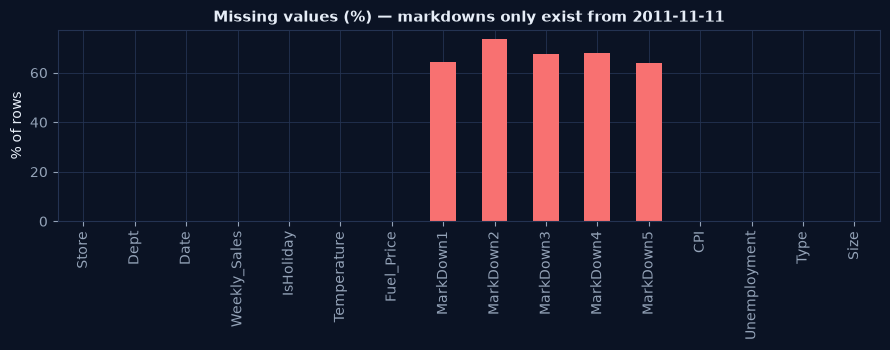

negative weekly sales (net returns): 1,285 rows · zero sales: 73 rows · duplicate store-department-weeks: 0


In [7]:
miss = raw.isna().mean().mul(100).round(1)
facts["missing_pct"] = miss[miss > 0].to_dict()
facts["markdown_first_week"] = str(feats.loc[feats[MARKDOWNS].notna().any(axis=1), "Date"].min().date())
facts["negative_sales_rows"] = int((sales[TARGET] < 0).sum())
facts["zero_sales_rows"] = int((sales[TARGET] == 0).sum())
ax = miss.plot.bar(color=[theme.CORAL if v > 0 else theme.TEAL for v in miss], figsize=(9, 3.6))
ax.set(title=f"Missing values (%) — markdowns only exist from {facts['markdown_first_week']}", ylabel="% of rows")
save("01_missing_values.png")
print(f"negative weekly sales (net returns): {facts['negative_sales_rows']:,} rows · zero sales: "
      f"{facts['zero_sales_rows']} rows · duplicate store-department-weeks: {facts['duplicate_rows']}")

| What we found | Decision | Why |
|---|---|---|
| 1,285 rows with **negative** sales (net returns) | set to 0 | returns are not demand; a department cannot sell less than nothing |
| Markdowns **missing** 64–74% of the time (none before 11 Nov 2011) | missing → 0, plus a `markdown_reported` flag | the flag lets the model tell "no markdown" from "not reported" |
| **Weeks with no row** for a department | count as 0 sales when building history; never used as a target | no record means nothing was sold that week |
| Temperature, fuel price, CPI, unemployment | complete, no action | — |
| Huge holiday spikes (up to $693K) | **kept** | they are real (Black Friday), and exactly what we need to predict |
| Duplicate rows | none | — |

## 5 · Feature engineering: history, date/time, holidays, promotion

| Feature | Meaning | Built from |
|---|---|---|
| `sales_lag_1` | sales last week | `Weekly_Sales`, 1 week back |
| `sales_lag_2` | sales 2 weeks ago | 2 weeks back |
| `sales_roll4` | average of the last 4 weeks | 1–4 weeks back |
| `sales_lag_52` | same week last year | 52 weeks back |
| `sales_yoy_jump` | how far this week rose above the 4 weeks before it, **last year** | 52 back − average of 53–56 back |
| `hol_super_bowl`, `hol_labor_day`, `hol_thanksgiving`, `hol_christmas` | which holiday this week is | `IsHoliday` + month (**date/time extraction**) |
| `pre_christmas` | the 2 weeks before Christmas: the biggest weeks, not flagged in the data | days from `Date` to 25 Dec (**date/time extraction**) |
| `month` | month of the year | `Date` (**date/time extraction**) |
| `promo_markdown`, `markdown_reported` | total markdown that week, and whether markdowns were reported | `MarkDown1–5` |
| `Type`, `Size`, `Dept` | store format, store size, product group | `stores.csv`, `train.csv` |

Only information from **before** the forecast week goes in. The code lives in `src/features.py` and is shared with the
Streamlit app, so the app builds its inputs exactly the way the model was trained:

In [8]:
print(inspect.getsource(build_table))

def build_table(sales, feats, stores):
    """Rows run from each department's first recorded week to ONE week past the data
    (that extra week has no target: it is the week the app forecasts)."""
    sales = sales.assign(**{TARGET: sales[TARGET].clip(lower=0)})  # net returns are not demand
    weeks = pd.date_range(sales.Date.min(), sales.Date.max() + pd.Timedelta(weeks=1), freq="7D")
    first = sales.groupby(["Store", "Dept"]).Date.min().rename("first").reset_index()
    grid = first.merge(pd.DataFrame({"Date": weeks}), how="cross")
    grid = grid[grid.Date >= grid["first"]].drop(columns="first")
    df = grid.merge(sales.drop(columns="IsHoliday"), on=KEYS, how="left").sort_values(KEYS, ignore_index=True)
    df["observed"] = df[TARGET].notna()

    # Historical sales. A week with no record counts as a week with no sales.
    past = df[TARGET].fillna(0).groupby([df.Store, df.Dept])
    lag = {k: past.shift(k) for k in (1, 2, 3, 4, 52, 53, 54, 55, 56)}
    df["sales_lag_1"], df["s

In [9]:
table = build_table(sales, feats, stores)
rows = model_rows(table)
facts["model_rows"] = len(rows)
facts["unrecorded_weeks_inside_history"] = int((~table.observed & (table.Date <= sales.Date.max())).sum())
print(f"rows built: {len(table):,} (one per store-department-week, plus next week to forecast)")
print(f"rows the model can learn from (a real week with 56 weeks of history behind it): {len(rows):,}, "
      f"{rows.Date.min().date()} → {rows.Date.max().date()}")
example = table[(table.Store == 35) & (table.Dept == 72) & table.Date.between("2011-11-04", "2011-12-30")]
display(example.set_index("Date")[[TARGET, *HISTORY, "hol_thanksgiving", "pre_christmas", "hol_christmas"]].round(0))

rows built: 465,384 (one per store-department-week, plus next week to forecast)
rows the model can learn from (a real week with 56 weeks of history behind it): 255,232, 2011-03-04 → 2012-10-26


,Weekly_Sales,sales_lag_1,sales_lag_2,sales_roll4,sales_lag_52,sales_yoy_jump,hol_thanksgiving,pre_christmas,hol_christmas
Date,,,,,,,,,
2011-11-04,76095.0,91001.0,100762.0,85599.0,66338.0,2988.0,0,0,0
2011-11-11,110254.0,76095.0,91001.0,87672.0,75510.0,12508.0,0,0,0
2011-11-18,92765.0,110254.0,76095.0,94528.0,59615.0,-7414.0,0,0,0
2011-11-25,649770.0,92765.0,110254.0,92529.0,627963.0,561167.0,1,0,0
2011-12-02,105459.0,649770.0,92765.0,232221.0,66617.0,-140739.0,0,0,0
2011-12-09,84718.0,105459.0,649770.0,239562.0,100271.0,-107155.0,0,0,0
2011-12-16,113555.0,84718.0,105459.0,233178.0,133769.0,-79848.0,0,1,0
2011-12-23,185794.0,113555.0,84718.0,238376.0,229484.0,-2671.0,0,1,0
2011-12-30,112986.0,185794.0,113555.0,122382.0,49798.0,-82737.0,0,0,1


*Store 35, department 72 (electronics) around Thanksgiving 2011:* before the week happens, `sales_yoy_jump` already
tells the model how big last year's Thanksgiving jump was.

## 6 · Exploratory Data Analysis

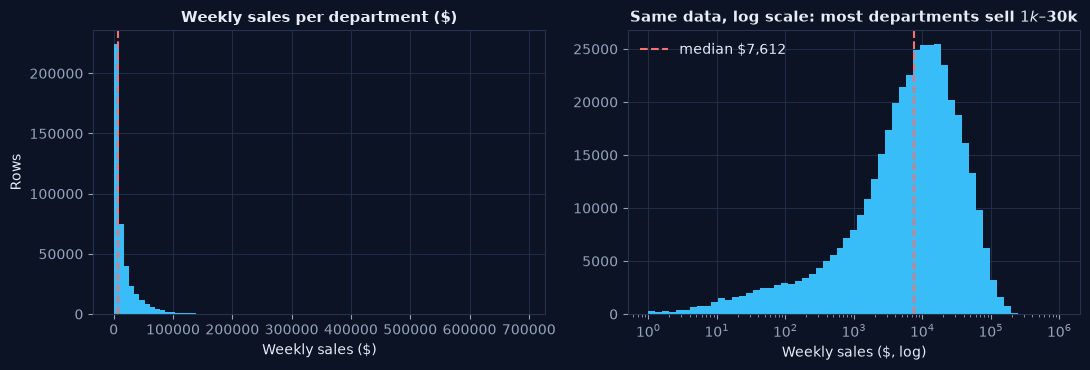

median $7,612 · mean $15,981 · max $693,099 → right-skewed: a few huge departments


In [10]:
obs = table[table.observed]
s = obs[TARGET]
facts["sales_summary"] = s.describe().round(1).to_dict()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(s, bins=80, color=theme.SKY)
ax[0].set(title="Weekly sales per department ($)", xlabel="Weekly sales ($)", ylabel="Rows")
ax[1].hist(s[s > 0], bins=np.logspace(0, 6, 60), color=theme.SKY)
ax[1].set(xscale="log", title="Same data, log scale: most departments sell $1k–$30k", xlabel="Weekly sales ($, log)")
for a in ax:
    a.axvline(s.median(), color=theme.CORAL, ls="--", label=f"median ${s.median():,.0f}")
ax[1].legend()
save("02_sales_distribution.png")
print(f"median ${s.median():,.0f} · mean ${s.mean():,.0f} · max ${s.max():,.0f} → right-skewed: a few huge departments")

**Right-skewed target.** Most department-weeks sell a few thousand dollars; a few departments sell hundreds of thousands. Errors are therefore reported in dollars, and big departments dominate them.

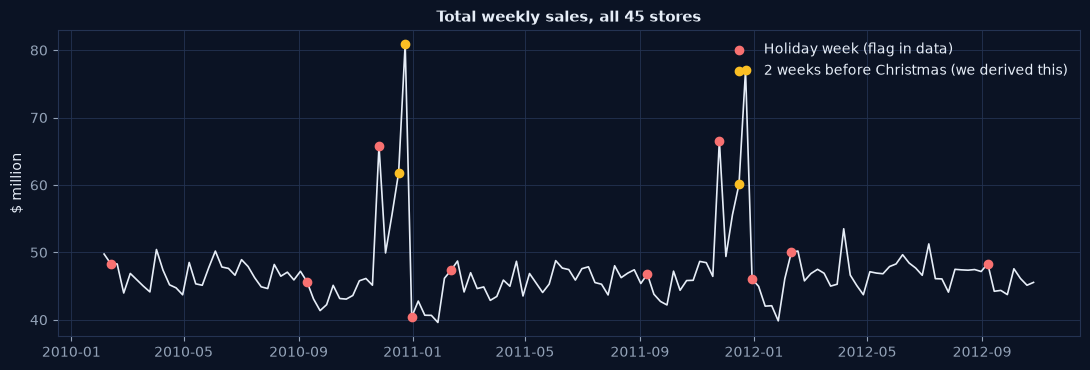

,2010-12-24,2011-12-23,2011-11-25,2010-11-26,2010-12-17,2011-12-16
$ million,80.9,77.0,66.6,65.8,61.8,60.1


In [11]:
wk = obs.groupby("Date")[TARGET].sum() / 1e6
kind = obs.groupby("Date")[HOLIDAYS].max()
flagged = kind[list(HOLIDAY_MONTH)].max(axis=1) == 1
facts["top_weeks_million"] = wk.sort_values(ascending=False).head(6).round(1).rename(lambda d: str(d.date())).to_dict()
plt.figure(figsize=(11, 3.8))
plt.plot(wk.index, wk.values, color=theme.TEXT, lw=1.2)
plt.scatter(wk.index[flagged], wk[flagged], color=theme.CORAL, zorder=3, label="Holiday week (flag in data)")
plt.scatter(wk.index[kind.pre_christmas == 1], wk[kind.pre_christmas == 1], color=theme.AMBER, zorder=3,
            label="2 weeks before Christmas (we derived this)")
plt.title("Total weekly sales, all 45 stores"); plt.ylabel("$ million"); plt.legend()
save("03_sales_over_time.png")
display(pd.Series(facts["top_weeks_million"], name="$ million").to_frame().T)

**Two spikes a year.** Thanksgiving week and the two weeks before Christmas are the biggest weeks. The pre-Christmas weeks are *not* flagged as holidays in the data, so we derive them from the date.

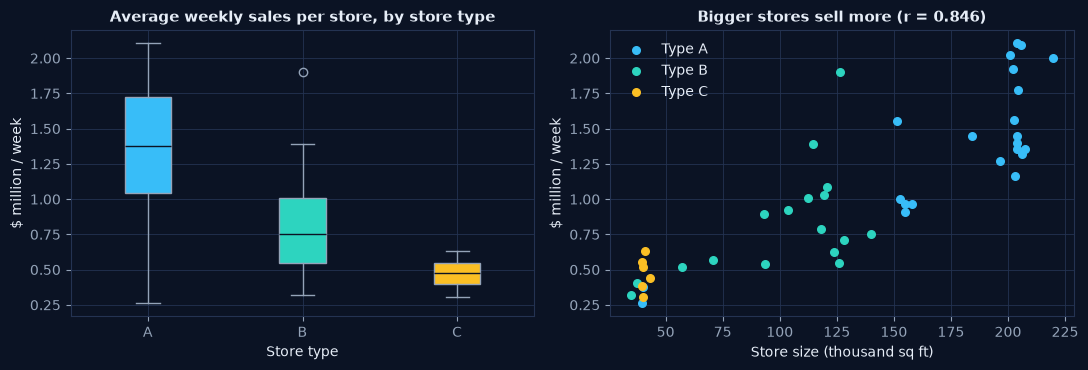

In [12]:
per_store = (obs.groupby(["Store", "Date"])[TARGET].sum().groupby("Store").mean().rename("avg_week")
             .reset_index().merge(stores, on="Store"))
facts["store_type_avg_week_million"] = (per_store.groupby("Type").avg_week.mean() / 1e6).round(2).to_dict()
facts["corr_store_size_vs_sales"] = round(float(per_store.Size.corr(per_store.avg_week)), 3)
type_color = {"A": theme.SKY, "B": theme.TEAL, "C": theme.AMBER}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
box = ax[0].boxplot([per_store.loc[per_store.Type == t, "avg_week"] / 1e6 for t in "ABC"], tick_labels=list("ABC"),
                    patch_artist=True, medianprops={"color": theme.BG}, whiskerprops={"color": theme.MUTED},
                    capprops={"color": theme.MUTED}, flierprops={"markeredgecolor": theme.MUTED})
for patch, t in zip(box["boxes"], "ABC"):
    patch.set(facecolor=type_color[t], edgecolor=theme.MUTED)
ax[0].set(title="Average weekly sales per store, by store type", xlabel="Store type", ylabel="$ million / week")
for t, g in per_store.groupby("Type"):
    ax[1].scatter(g.Size / 1000, g.avg_week / 1e6, label=f"Type {t}", s=30, color=type_color[t])
ax[1].set(title=f"Bigger stores sell more (r = {facts['corr_store_size_vs_sales']})",
          xlabel="Store size (thousand sq ft)", ylabel="$ million / week"); ax[1].legend()
save("04_store_type_size.png")

**Store matters.** Type A stores sell the most, and store size alone correlates strongly with store sales. `Type` and `Size` stay as inputs.

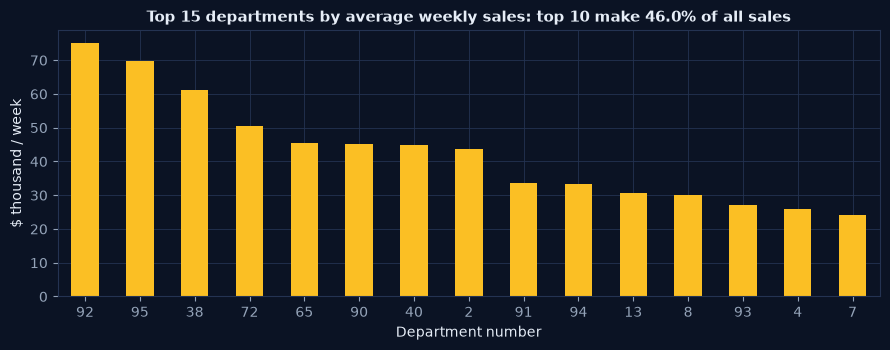

In [13]:
dept_avg = obs.groupby("Dept")[TARGET].mean().sort_values(ascending=False)
dept_total = obs.groupby("Dept")[TARGET].sum().sort_values(ascending=False)
facts["top10_dept_share_pct"] = round(float(dept_total.head(10).sum() / dept_total.sum() * 100), 1)
facts["top5_departments_avg_week"] = dept_avg.head(5).round(0).to_dict()
ax = (dept_avg.head(15) / 1000).plot.bar(color=theme.AMBER, figsize=(9, 3.6), rot=0)
ax.set(title=f"Top 15 departments by average weekly sales: top 10 make {facts['top10_dept_share_pct']}% of all sales",
       xlabel="Department number", ylabel="$ thousand / week")
save("05_departments.png")

**Product matters.** A handful of departments carry almost half of all sales, so the department (product group) is an input.

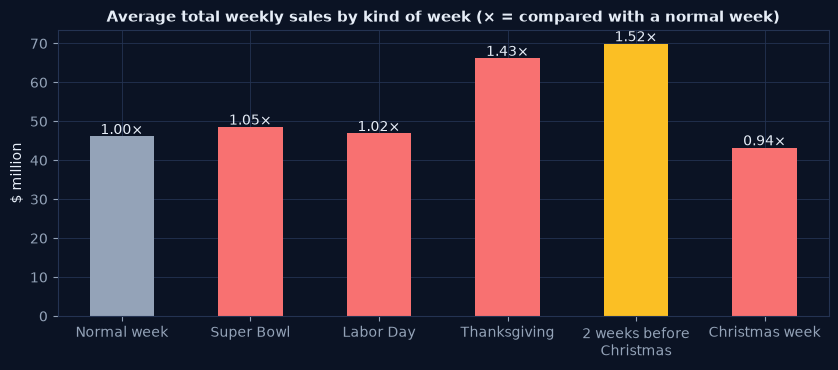

In [14]:
WEEK_KINDS = {"hol_super_bowl": "Super Bowl", "hol_labor_day": "Labor Day", "hol_thanksgiving": "Thanksgiving",
              "pre_christmas": "2 weeks before\nChristmas", "hol_christmas": "Christmas week"}
week_kind = pd.Series("Normal week", index=obs.index)
for col, name in WEEK_KINDS.items():
    week_kind[obs[col] == 1] = name
by_kind = obs.assign(kind=week_kind).groupby(["Date", "kind"])[TARGET].sum().groupby("kind").mean() / 1e6
by_kind = by_kind.reindex(["Normal week", *WEEK_KINDS.values()])
facts["avg_week_million_by_kind"] = {k.replace("\n", " "): round(float(v), 2) for k, v in by_kind.items()}
ax = by_kind.plot.bar(color=[theme.MUTED] + [theme.CORAL] * 3 + [theme.AMBER, theme.CORAL], figsize=(8.5, 3.8), rot=0)
for i, v in enumerate(by_kind):
    ax.text(i, v + 0.6, f"{v / by_kind.iloc[0]:.2f}×", ha="center")
ax.set(title="Average total weekly sales by kind of week (× = compared with a normal week)", ylabel="$ million", xlabel="")
save("06_holiday_effect.png")

**Holidays multiply sales.** Thanksgiving week ≈ 1.4× and the pre-Christmas weeks ≈ 1.5× a normal week, while Christmas week itself dips. Because a holiday *multiplies* sales, the polynomial model's interaction terms (history × holiday) are the natural tool.

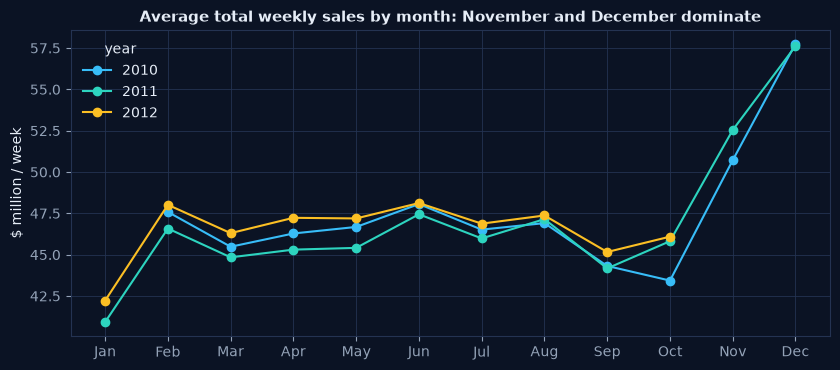

In [15]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly = obs.groupby(["year", "month", "Date"])[TARGET].sum().groupby(["year", "month"]).mean().unstack(0) / 1e6
ax = monthly.plot(marker="o", figsize=(8.5, 3.8))
ax.set(title="Average total weekly sales by month: November and December dominate", xlabel="", ylabel="$ million / week",
       xticks=range(1, 13), xticklabels=MONTHS)
save("07_monthly_seasonality.png")

**Month matters, and the pattern repeats every year**, which is why *the same week last year* is such a strong clue.

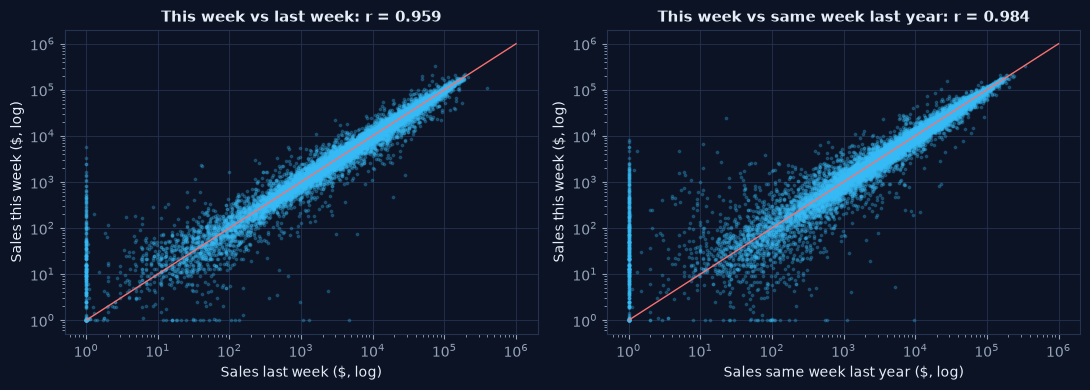

In [16]:
NUMERIC = [TARGET, *HISTORY, "promo_markdown", "Size", *ECONOMIC]
facts["corr_with_target"] = {c: round(float(rows[TARGET].corr(rows[c])), 3) for c in NUMERIC[1:]}
sample = rows.sample(20000, random_state=SEED)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, col, label in [(ax[0], "sales_lag_1", "last week"), (ax[1], "sales_lag_52", "same week last year")]:
    a.scatter(sample[col] + 1, sample[TARGET] + 1, s=3, alpha=0.25, color=theme.SKY)
    a.plot([1, 1e6], [1, 1e6], color=theme.CORAL, lw=1)
    a.set(xscale="log", yscale="log", xlabel=f"Sales {label} ($, log)", ylabel="Sales this week ($, log)",
          title=f"This week vs {label}: r = {facts['corr_with_target'][col]}")
save("08_history_vs_sales.png")

**History is the strongest clue.** This week's sales sit close to last week's and to the same week last year, which is why the history features lead the model.

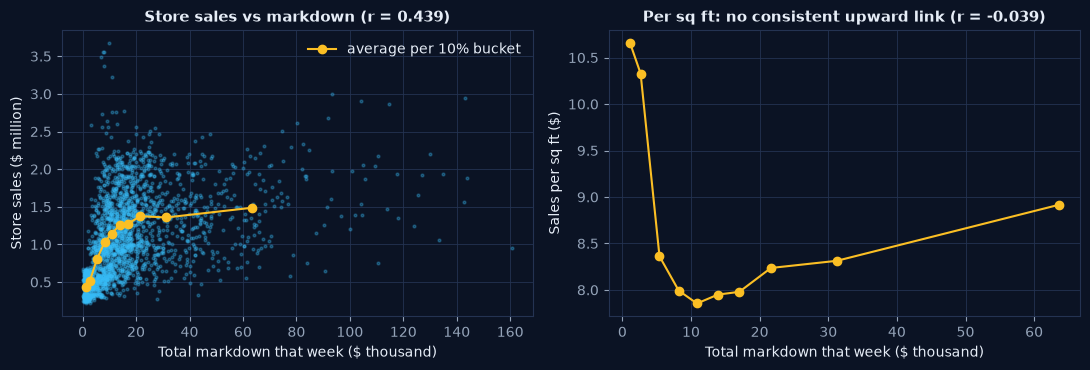

In [17]:
sw = obs[obs.markdown_reported == 1].groupby(["Store", "Date"]).agg(
    sales=(TARGET, "sum"), markdown=("promo_markdown", "first"), size=("Size", "first")).reset_index()
sw["sales_per_sqft"] = sw.sales / sw["size"]
facts["corr_markdown_vs_store_sales"] = round(float(sw.markdown.corr(sw.sales)), 3)
facts["corr_markdown_vs_sales_per_sqft"] = round(float(sw.markdown.corr(sw.sales_per_sqft)), 3)
binned = sw.groupby(pd.qcut(sw.markdown, 10, duplicates="drop"), observed=True)[["markdown", "sales", "sales_per_sqft"]].mean()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(sw.markdown / 1000, sw.sales / 1e6, s=4, alpha=0.3, color=theme.SKY)
ax[0].plot(binned.markdown / 1000, binned.sales / 1e6, color=theme.AMBER, marker="o", label="average per 10% bucket")
ax[0].set(title=f"Store sales vs markdown (r = {facts['corr_markdown_vs_store_sales']})",
          xlabel="Total markdown that week ($ thousand)", ylabel="Store sales ($ million)"); ax[0].legend()
ax[1].plot(binned.markdown / 1000, binned.sales_per_sqft, color=theme.AMBER, marker="o")
ax[1].set(title=f"Per sq ft: no consistent upward link (r = {facts['corr_markdown_vs_sales_per_sqft']})",
          xlabel="Total markdown that week ($ thousand)", ylabel="Sales per sq ft ($)")
save("09_markdown_vs_sales.png")

**Promotions look powerful, but it's store size.** Big stores run bigger markdowns *and* sell more. Per square foot the link almost disappears, so we expect markdowns to add little once history is known.

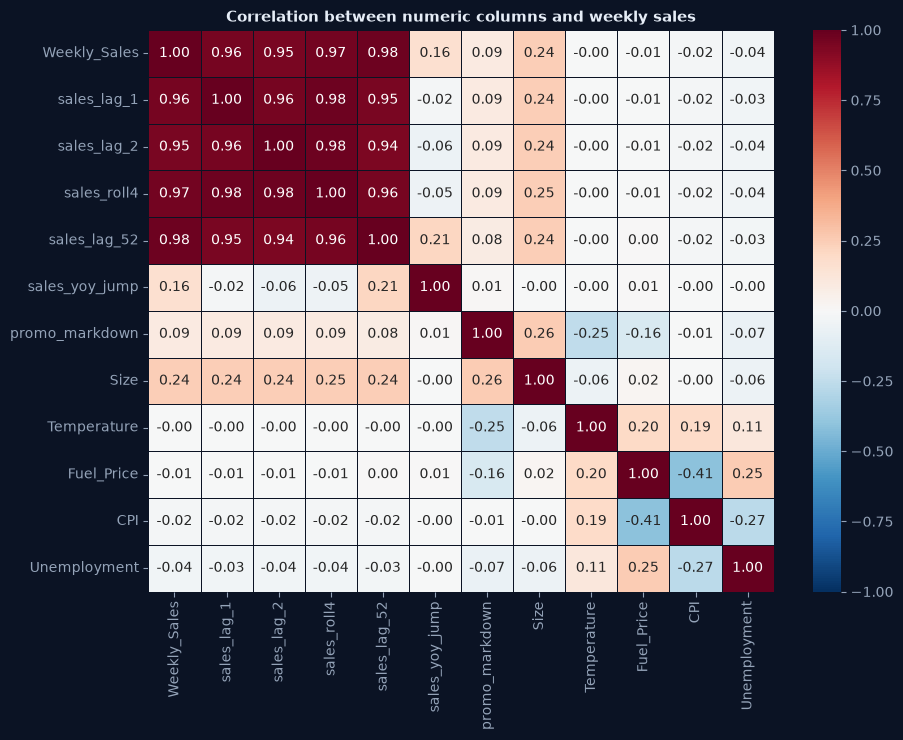

In [18]:
plt.figure(figsize=(9.5, 7.5))
sns.heatmap(rows[NUMERIC].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=theme.BG)
plt.title("Correlation between numeric columns and weekly sales")
save("10_correlation_heatmap.png")

**Economic data barely moves with sales** (temperature, fuel price, CPI, unemployment all ≈ 0). Section 10 tests whether they help anyway.

## 7 · Train/test design: never peek at the future

* **Test set** = the last 20% of weeks, locked away until the very end. The model is chosen without ever seeing them.
* **Cross-validation** = 5 expanding-window folds inside the training weeks: always train on earlier weeks, validate
  on the next block. A random split would let the model learn from *next* week to predict *this* week (leakage).
* Every preprocessing step (imputation, scaling, encoding, polynomial terms) sits inside one scikit-learn `Pipeline`,
  so it is fitted on training rows only and then applied unchanged to validation/test rows.

In [19]:
TEST_FRACTION = 0.2
data = rows.reset_index(drop=True)
weeks = np.sort(data.Date.unique())
cutoff = weeks[-round(len(weeks) * TEST_FRACTION)]
train, test = data[data.Date < cutoff].reset_index(drop=True), data[data.Date >= cutoff].reset_index(drop=True)


def week_folds(dates, n_splits=5):
    """Expanding-window CV on whole weeks: train on the past, validate on the next block of weeks."""
    weeks = np.sort(dates.unique())
    for tr, va in TimeSeriesSplit(n_splits).split(weeks):
        yield np.flatnonzero(dates.isin(weeks[tr])), np.flatnonzero(dates.isin(weeks[va]))


folds = list(week_folds(train.Date))
results["data"] = {"rows": len(data), "train_rows": len(train), "test_rows": len(test),
                   "train_weeks": [str(train.Date.min().date()), str(train.Date.max().date()), int(train.Date.nunique())],
                   "test_weeks": [str(test.Date.min().date()), str(test.Date.max().date()), int(test.Date.nunique())],
                   "series": int(data.groupby(["Store", "Dept"]).ngroups)}
results["cv_folds"] = [[str(train.Date.iloc[va].min().date()), str(train.Date.iloc[va].max().date())] for _, va in folds]
plan = [{"part": f"CV fold {i}", "learns from weeks up to": str(train.Date.iloc[tr].max().date()),
         "checked on": f"{a} → {b}", "rows checked": len(va)}
        for i, ((tr, va), (a, b)) in enumerate(zip(folds, results["cv_folds"]), 1)]
plan.append({"part": "FINAL TEST", "learns from weeks up to": results["data"]["train_weeks"][1],
             "checked on": " → ".join(results["data"]["test_weeks"][:2]), "rows checked": len(test)})
display(pd.DataFrame(plan).set_index("part"))

,learns from weeks up to,checked on,rows checked
part,,,
CV fold 1,2011-06-10,2011-06-17 → 2011-08-26,32008
CV fold 2,2011-08-26,2011-09-02 → 2011-11-11,32279
CV fold 3,2011-11-11,2011-11-18 → 2012-01-27,32496
CV fold 4,2012-01-27,2012-02-03 → 2012-04-13,32477
CV fold 5,2012-04-13,2012-04-20 → 2012-06-29,32311
FINAL TEST,2012-06-29,2012-07-06 → 2012-10-26,50073


## 8 · Baselines and the two regression models

**Baselines: what a store manager might do without ML.** They set the bar the models must clear:
1. *Naive*: next week = last week.
2. *Seasonal naive*: next week = the same week last year.
3. *Seasonal rule*: average of the last 4 weeks + how much this week jumped last year.

**Models**
* **Linear Regression**: a weighted sum of the inputs.
* **Polynomial Regression (degree 2)**: adds squares and pairwise products of the history, promotion and holiday
  inputs, e.g. *last week's sales × Thanksgiving*, so a holiday can **multiply** a department's sales instead of
  adding the same dollars to every department.

In [20]:
MODELS = {"Linear Regression": 1, "Polynomial Regression (degree 2)": 2}
NAIVE, RULE = "Naive: last week's sales", "Seasonal rule: last 4 weeks + last year's jump"
BASELINES = {NAIVE: lambda d: d.sales_lag_1,
             "Seasonal naive: same week last year": lambda d: d.sales_lag_52,
             RULE: lambda d: (d.sales_roll4 + d.sales_yoy_jump).clip(lower=0)}
COLORS = theme.BASELINES + theme.MODELS
SHORT = ["Naive", "Seasonal\nnaive", "Seasonal\nrule", "Linear", "Poly (2)"]


def make_model(degree, linear=LINEAR, categorical=CATEGORICAL):
    """degree 1 = Linear Regression; degree 2+ = Polynomial Regression on the history/promo/holiday columns."""
    steps = [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
    if degree > 1:
        steps.append(("poly", PolynomialFeatures(degree, include_bias=False)))
    prep = ColumnTransformer([
        ("poly", Pipeline(steps), POLY),
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), linear),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([("prep", prep), ("model", LinearRegression())])


def predict(model, X):
    return np.clip(model.predict(X), 0, None)  # a department cannot sell less than nothing


def metrics(y, p, holiday):
    y, p = np.asarray(y), np.asarray(p)
    w = np.where(holiday, 5, 1)  # the Kaggle competition's own metric counts holiday weeks 5×
    return {"MAE": mean_absolute_error(y, p), "MSE": mean_squared_error(y, p), "RMSE": mean_squared_error(y, p) ** 0.5,
            "R2": r2_score(y, p), "WMAE": float(np.sum(w * np.abs(y - p)) / w.sum()), "bias": float(np.mean(y - p))}


def rnd(d, n=3):
    return {k: round(float(v), n) for k, v in d.items()}


make_model(2)  # the full preprocessing + model pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('poly', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 9 · Cross-validation (5 folds, training weeks only)

In [21]:
start = time.time()
cv_rows, cv_pred = [], {n: np.full(len(train), np.nan) for n in [*BASELINES, *MODELS]}
for fold, (tr, va) in enumerate(folds, 1):
    a, b = train.iloc[tr], train.iloc[va]
    for name, rule in BASELINES.items():
        cv_pred[name][va] = rule(b).values
    for name, degree in MODELS.items():
        cv_pred[name][va] = predict(make_model(degree).fit(a[FEATURES], a[TARGET]), b[FEATURES])
    for name in cv_pred:
        cv_rows.append({"model": name, "fold": fold, **metrics(b[TARGET], cv_pred[name][va], b.IsHoliday)})
cv = pd.DataFrame(cv_rows)
results["cv"] = {n: {"mean": rnd(g.drop(columns=["model", "fold"]).mean().to_dict()),
                     "std": rnd(g.drop(columns=["model", "fold"]).std().to_dict())} for n, g in cv.groupby("model", sort=False)}
results["cv_mae_per_fold"] = {n: g.MAE.round(0).tolist() for n, g in cv.groupby("model", sort=False)}

seen = ~np.isnan(cv_pred[NAIVE])
special = train[HOLIDAYS].max(axis=1).values == 1
err = {n: np.abs(train[TARGET].values - p) for n, p in cv_pred.items()}
results["cv_mae_by_week_kind"] = {n: {"normal_weeks": round(float(e[seen & ~special].mean()), 1),
                                      "holiday_and_pre_christmas_weeks": round(float(e[seen & special].mean()), 1)}
                                  for n, e in err.items()}
print(f"5 folds × 5 methods in {time.time() - start:.0f}s")
display(pd.DataFrame({n: r["mean"] for n, r in results["cv"].items()}).T[["MAE", "RMSE", "MSE", "R2", "WMAE"]].round(1))
per_fold = pd.DataFrame(results["cv_mae_per_fold"], index=[f"fold {i}" for i in range(1, 6)]).T
per_fold["folds 4-5 (training includes a holiday season)"] = per_fold[["fold 4", "fold 5"]].mean(axis=1)
display(per_fold.round(0).astype(int))
display(pd.DataFrame(results["cv_mae_by_week_kind"]).T)

5 folds × 5 methods in 5s


,MAE,RMSE,MSE,R2,WMAE
Naive: last week's sales,2231.8,6107.2,57896421.3,0.9,2647.2
Seasonal naive: same week last year,1892.6,4057.2,16641251.9,1.0,1921.8
Seasonal rule: last 4 weeks + last year's jump,1575.3,3613.8,13593072.0,1.0,1641.6
Linear Regression,1710.5,4010.5,18427611.0,1.0,1845.8
Polynomial Regression (degree 2),1668.5,3960.5,18278721.8,1.0,1787.4


,fold 1,fold 2,fold 3,fold 4,fold 5,folds 4-5 (training includes a holiday season)
Naive: last week's sales,1464,1746,4378,1991,1579,1785
Seasonal naive: same week last year,1777,1787,2098,1891,1911,1901
Seasonal rule: last 4 weeks + last year's jump,1295,1378,1914,1532,1758,1645
Linear Regression,1410,1413,2457,1650,1621,1636
Polynomial Regression (degree 2),1334,1346,2479,1670,1513,1592


,normal_weeks,holiday_and_pre_christmas_weeks
Naive: last week's sales,1867.2,5213.1
Seasonal naive: same week last year,1823.5,2455.5
Seasonal rule: last 4 weeks + last year's jump,1509.0,2119.7
Linear Regression,1577.9,2795.2
Polynomial Regression (degree 2),1532.2,2785.3


**Reading this honestly.** The seasonal rule has the lowest average CV error. Almost all of its lead comes from
**fold 3** (Nov 2011–Jan 2012): in that fold the models had never seen a holiday season, because "same week last
year" only exists from Feb 2011, while the rule has "holiday jumps repeat" built in. In folds 4–5, whose training data
does include a holiday season, Polynomial Regression has the lowest average error. We pick between the two regression models by CV RMSE,
fixed **before** opening the test weeks.

## 10 · Feature selection: do store IDs and economic data help?

In [22]:
def cv_mae(degree, linear=LINEAR, categorical=CATEGORICAL):
    cols = POLY + linear + categorical
    errs = []
    for tr, va in folds:
        m = make_model(degree, linear, categorical).fit(train.iloc[tr][cols], train.iloc[tr][TARGET])
        errs.append(mean_absolute_error(train.iloc[va][TARGET], predict(m, train.iloc[va][cols])))
    return float(np.mean(errs))


feature_sets = {"All columns (+ store ID + economic data)": (LINEAR + ECONOMIC, CATEGORICAL + ["Store"]),
                "Without store ID": (LINEAR + ECONOMIC, CATEGORICAL),
                "Without store ID and economic data (chosen)": (LINEAR, CATEGORICAL)}
results["feature_selection_cv_mae"] = {n: round(cv_mae(2, *cols), 1) for n, cols in feature_sets.items()}
display(pd.Series(results["feature_selection_cv_mae"], name="CV MAE ($), Polynomial degree 2").to_frame())

,"CV MAE ($), Polynomial degree 2"
All columns (+ store ID + economic data),1691.4
Without store ID,1680.7
Without store ID and economic data (chosen),1668.5


Removing the store ID (already described by store type and size) and the four economic columns *lowers* the error slightly and makes the model simpler, so they are left out.

## 11 · Choosing the polynomial degree

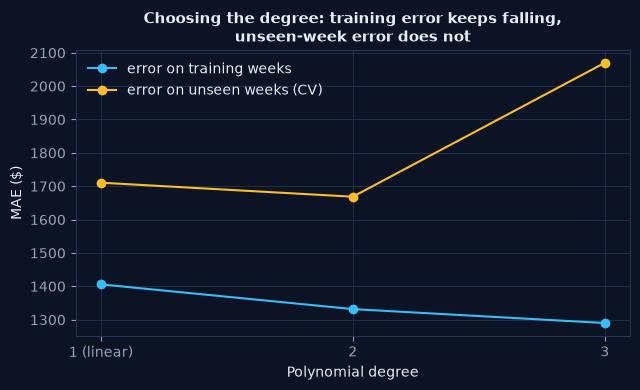

,train_MAE,cv_MAE
1,1405.8,1710.5
2,1331.7,1668.5
3,1289.9,2069.8


In [23]:
curve = {}
for degree in (1, 2, 3):
    tr_err, va_err = [], []
    for tr, va in folds:
        a, b = train.iloc[tr], train.iloc[va]
        m = make_model(degree).fit(a[FEATURES], a[TARGET])
        tr_err.append(mean_absolute_error(a[TARGET], predict(m, a[FEATURES])))
        va_err.append(mean_absolute_error(b[TARGET], predict(m, b[FEATURES])))
    curve[degree] = {"train_MAE": round(float(np.mean(tr_err)), 1), "cv_MAE": round(float(np.mean(va_err)), 1)}
results["degree_check"] = curve
degs = list(curve)
plt.figure(figsize=(6.5, 4))
plt.plot(degs, [curve[d]["train_MAE"] for d in degs], marker="o", color=theme.SKY, label="error on training weeks")
plt.plot(degs, [curve[d]["cv_MAE"] for d in degs], marker="o", color=theme.AMBER, label="error on unseen weeks (CV)")
plt.xticks(degs, ["1 (linear)", "2", "3"]); plt.xlabel("Polynomial degree"); plt.ylabel("MAE ($)")
plt.title("Choosing the degree: training error keeps falling,\nunseen-week error does not"); plt.legend()
save("12_degree_check.png")
display(pd.DataFrame(curve).T)

**Degree 2 is the sweet spot.** Degree 3 fits the training weeks even better but does clearly worse on unseen weeks: classic over-fitting.

## 12 · Final test on 17 unseen weeks

chosen on cross-validation: Polynomial Regression (degree 2)


,MAE,RMSE,MSE,R2,WMAE,error cut vs naive,error cut vs rule
Naive: last week's sales,1555.054,3490.155,1.218118e+07,0.975,1663.506,+0.0%,-12.2%
Seasonal naive: same week last year,1683.276,3549.850,1.260144e+07,0.974,1705.431,-8.2%,-21.4%
Seasonal rule: last 4 weeks + last year's jump,1386.289,3062.314,9.377769e+06,0.981,1400.424,+10.9%,+0.0%
Linear Regression,1308.799,2655.465,7.051495e+06,0.985,1344.893,+15.8%,+5.6%
Polynomial Regression (degree 2),1276.866,2543.734,6.470585e+06,0.987,1291.311,+17.9%,+7.9%


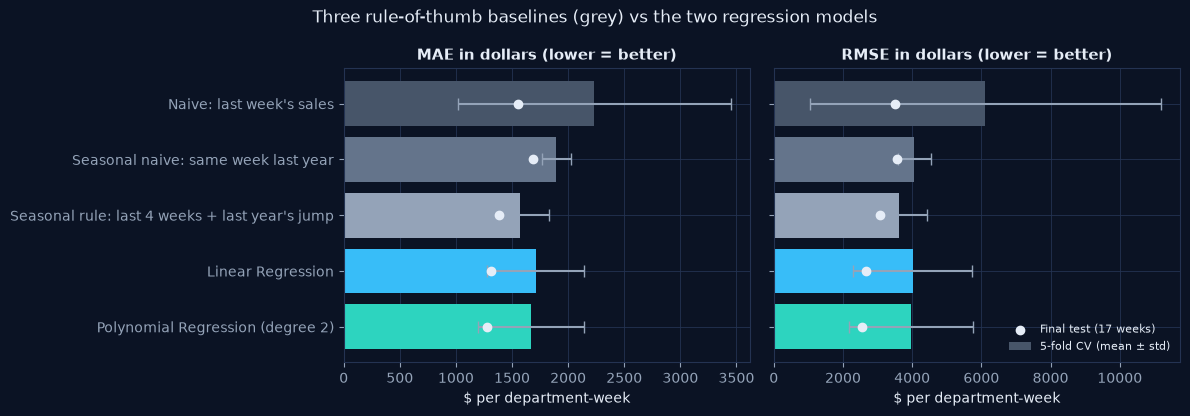

In [24]:
best_name = min(MODELS, key=lambda n: results["cv"][n]["mean"]["RMSE"])  # chosen on CV, before opening the test weeks
fitted = {n: make_model(d).fit(train[FEATURES], train[TARGET]) for n, d in MODELS.items()}
test_pred = {**{n: rule(test).values for n, rule in BASELINES.items()},
             **{n: predict(m, test[FEATURES]) for n, m in fitted.items()}}
results["best_model"] = best_name
results["train_fit"] = {n: rnd(metrics(train[TARGET], predict(m, train[FEATURES]), train.IsHoliday)) for n, m in fitted.items()}
results["test"] = {n: rnd(metrics(test[TARGET], p, test.IsHoliday)) for n, p in test_pred.items()}
for ref, key in ((NAIVE, "naive"), (RULE, "rule")):
    results[f"test_mae_change_vs_{key}_pct"] = {n: round((1 - v["MAE"] / results["test"][ref]["MAE"]) * 100, 1)
                                                for n, v in results["test"].items()}
best, pred = fitted[best_name], test_pred[best_name]
scores = pd.DataFrame(results["test"]).T[["MAE", "RMSE", "MSE", "R2", "WMAE"]]
scores["error cut vs naive"] = pd.Series(results["test_mae_change_vs_naive_pct"]).map("{:+.1f}%".format)
scores["error cut vs rule"] = pd.Series(results["test_mae_change_vs_rule_pct"]).map("{:+.1f}%".format)
print("chosen on cross-validation:", best_name)
display(scores.round(3))

names = list(results["cv"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, key in zip(ax, ["MAE", "RMSE"]):
    a.barh(names, [results["cv"][n]["mean"][key] for n in names], xerr=[results["cv"][n]["std"][key] for n in names],
           color=COLORS, capsize=4, ecolor=theme.MUTED, label="5-fold CV (mean ± std)")
    a.scatter([results["test"][n][key] for n in names], names, color=theme.TEXT, zorder=3, label="Final test (17 weeks)")
    a.set(title=f"{key} in dollars (lower = better)", xlabel="$ per department-week")
    a.invert_yaxis()
ax[1].tick_params(labelleft=False)  # same rows as the left panel
ax[1].legend(loc="lower right", fontsize=8)
fig.suptitle("Three rule-of-thumb baselines (grey) vs the two regression models")
save("11_model_comparison.png")

## 13 · Residuals, week-by-week error and the holiday close-up

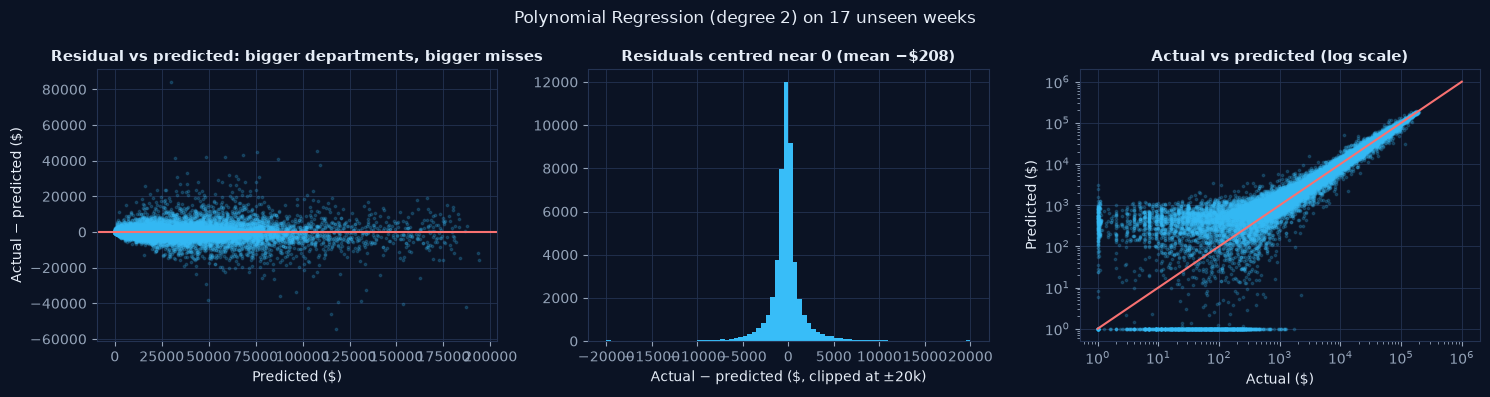

,mean,std,abs_p50,abs_p80,abs_p90
$,-208.3,2535.2,627.9,1712.2,2952.4


In [25]:
res = test[TARGET].values - pred
absr = np.abs(res)
results["residuals"] = rnd({"mean": res.mean(), "std": res.std(), "abs_p50": np.percentile(absr, 50),
                            "abs_p80": np.percentile(absr, 80), "abs_p90": np.percentile(absr, 90)}, 1)
sign = "−" if res.mean() < 0 else "+"
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(pred, res, s=3, alpha=0.2, color=theme.SKY); ax[0].axhline(0, color=theme.CORAL)
ax[0].set(title="Residual vs predicted: bigger departments, bigger misses", xlabel="Predicted ($)", ylabel="Actual − predicted ($)")
ax[1].hist(np.clip(res, -20000, 20000), bins=80, color=theme.SKY)
ax[1].set(title=f"Residuals centred near 0 (mean {sign}${abs(res.mean()):,.0f})", xlabel="Actual − predicted ($, clipped at ±20k)")
ax[2].scatter(test[TARGET] + 1, pred + 1, s=3, alpha=0.2, color=theme.SKY); ax[2].plot([1, 1e6], [1, 1e6], color=theme.CORAL)
ax[2].set(xscale="log", yscale="log", title="Actual vs predicted (log scale)", xlabel="Actual ($)", ylabel="Predicted ($)")
fig.suptitle(f"{best_name} on {test.Date.nunique()} unseen weeks")
save("13_residuals.png")
display(pd.Series(results["residuals"], name="$").to_frame().T)

Errors are centred near zero with no pattern over the prediction range, but they grow with department size (more dollars at stake). Very small departments (<$100/week) are over-forecast in relative terms.

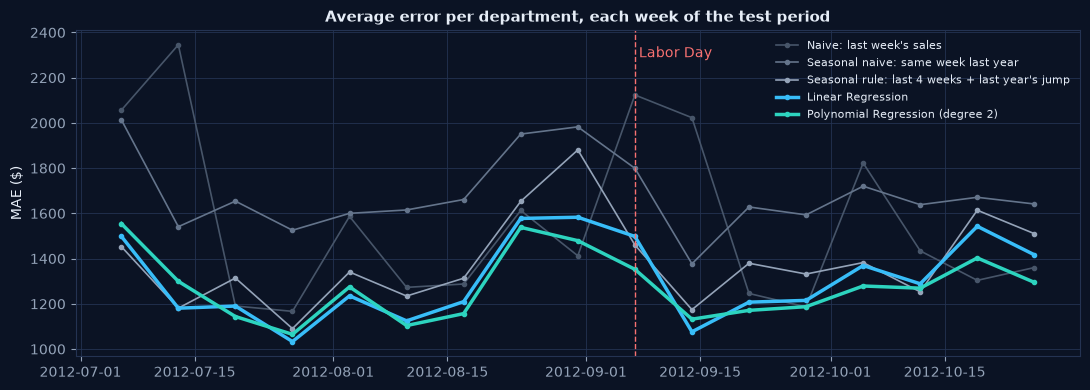

In [26]:
weekly = pd.DataFrame({n: np.abs(test[TARGET].values - p) for n, p in test_pred.items()}).groupby(test.Date).mean()
plt.figure(figsize=(11, 4))
for n, c in zip(weekly.columns, COLORS):
    plt.plot(weekly.index, weekly[n], marker="o", ms=3, color=c, label=n, lw=2.5 if n in MODELS else 1.2)
labor = test.loc[test.hol_labor_day == 1, "Date"].min()
plt.axvline(labor, color=theme.CORAL, ls="--", lw=1)
plt.text(labor, plt.ylim()[1] * 0.95, " Labor Day", color=theme.CORAL)
plt.title("Average error per department, each week of the test period"); plt.ylabel("MAE ($)"); plt.legend(fontsize=8)
save("14_weekly_error.png")

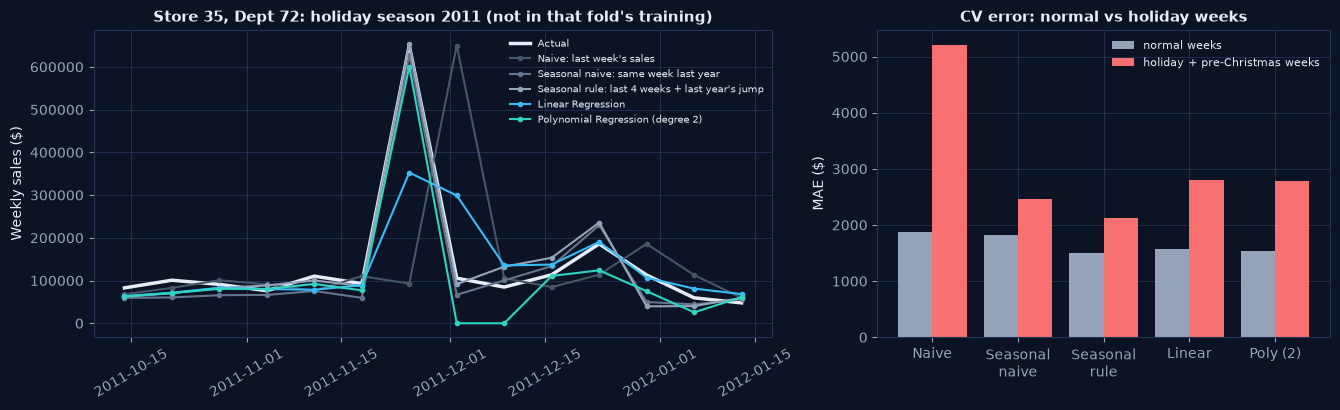

In [27]:
thx = train[(train.hol_thanksgiving == 1) & seen & (train.sales_lag_1 > 20000)]
pick = thx.loc[(thx[TARGET] - thx.sales_lag_1).idxmax(), ["Store", "Dept"]]
ser = train.index[(train.Store == pick.Store) & (train.Dept == pick.Dept) & seen
                  & train.Date.between("2011-10-14", "2012-01-13")]
results["holiday_example"] = {"store": int(pick.Store), "dept": int(pick.Dept)}
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax[0].plot(train.Date[ser], train[TARGET][ser], color=theme.TEXT, lw=2.5, label="Actual")
for n, c in zip(cv_pred, COLORS):
    ax[0].plot(train.Date[ser], cv_pred[n][ser], color=c, marker="o", ms=3, label=n)
ax[0].set(title=f"Store {int(pick.Store)}, Dept {int(pick.Dept)}: holiday season 2011 (not in that fold's training)",
          ylabel="Weekly sales ($)")
ax[0].legend(fontsize=7); ax[0].tick_params(axis="x", rotation=30)
kinds = results["cv_mae_by_week_kind"]
x = np.arange(len(kinds))
ax[1].bar(x - 0.2, [kinds[n]["normal_weeks"] for n in kinds], 0.4, label="normal weeks", color=theme.MUTED)
ax[1].bar(x + 0.2, [kinds[n]["holiday_and_pre_christmas_weeks"] for n in kinds], 0.4,
          label="holiday + pre-Christmas weeks", color=theme.CORAL)
ax[1].set_xticks(x, SHORT); ax[1].set(title="CV error: normal vs holiday weeks", ylabel="MAE ($)"); ax[1].legend(fontsize=8)
save("15_holiday_season.png")

**The honest weak spot: big holiday spikes.** In the fold where the models had never seen a holiday season, the rule
caught the Black Friday spike best. The polynomial model caught the spike too, but its squared terms then **over-reacted
to a value far outside its training range** and forecast $0 for the next two weeks. That is the known weakness of polynomial regression, and the reason the app keeps
what-if inputs inside the training range and shows the rule next to the model.

## 14 · Which inputs matter?

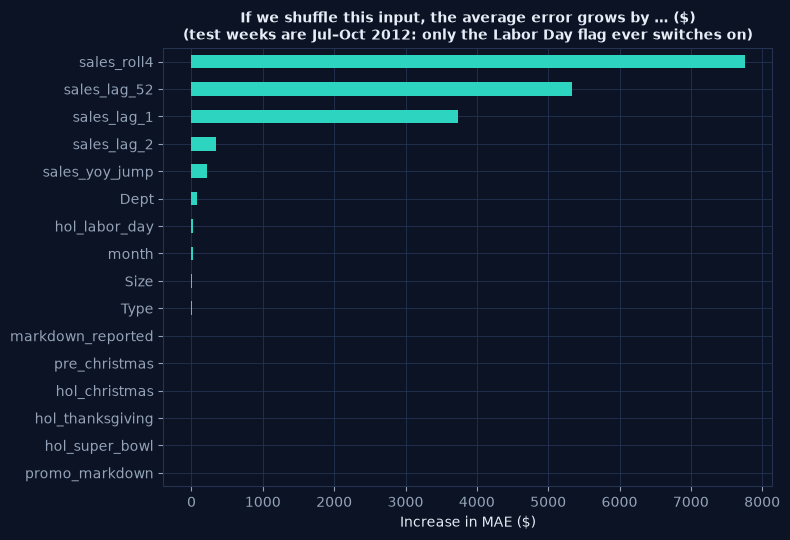

In [28]:
pi = permutation_importance(best, test[FEATURES], test[TARGET], scoring="neg_mean_absolute_error",
                            n_repeats=5, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
results["importance_mae_increase"] = {k: round(float(v), 1) for k, v in imp.sort_values(ascending=False).items()}
imp.plot.barh(color=theme.TEAL, figsize=(8, 5.5))
plt.title("If we shuffle this input, the average error grows by … ($)\n"
          "(test weeks are Jul–Oct 2012: only the Labor Day flag ever switches on)", fontsize=10)
plt.xlabel("Increase in MAE ($)")
save("16_feature_importance.png")

Recent history (last 4 weeks, last week) and the same week last year carry the forecast. Department and month add a little. Markdowns add essentially nothing once history is known, which matches section 6.

## 15 · Save the model for the Streamlit app

In [29]:
# Misses grow with department size, so the app's range is a percentage of the forecast, per size group.
edges = np.quantile(pred, [0.2, 0.4, 0.6, 0.8])
band = np.searchsorted(edges, pred)
pct = absr / np.maximum(pred, 1.0)
bands = {"edges": edges.round(1).tolist(), "p80_pct": [round(float(np.percentile(pct[band == b], 80)), 3) for b in range(5)]}
results["error_bands"] = bands
joblib.dump({"pipeline": best, "name": best_name, "features": FEATURES, "error_bands": bands,
             "train_weeks": results["data"]["train_weeks"], "test_weeks": results["data"]["test_weeks"],
             "test_metrics": results["test"][best_name], "naive_test_metrics": results["test"][NAIVE],
             "rule_test_metrics": results["test"][RULE], "sklearn_version": sklearn.__version__,
             # what-if inputs the app lets users change: keep them inside what the model was trained on
             "input_ranges": {c: [float(train[c].min()), float(train[c].max())] for c in ("sales_lag_1", "promo_markdown")}},
            MOD / "best_model.joblib")
(REP / "results.json").write_text(json.dumps(results, indent=2))
(REP / "eda.json").write_text(json.dumps(facts, indent=2, default=str))

reloaded = joblib.load(MOD / "best_model.joblib")["pipeline"]
assert np.allclose(predict(reloaded, test[FEATURES].head(1000)), pred[:1000])  # saving/loading works
print("saved and re-loaded: models/best_model.joblib · wrote reports/results.json and reports/eda.json")
display(pd.DataFrame({"forecast size from ($)": [0, *bands["edges"]],
                      "8 of 10 test misses within": [f"±{p:.0%}" for p in bands["p80_pct"]]}))

saved and re-loaded: models/best_model.joblib · wrote reports/results.json and reports/eda.json


,forecast size from ($),8 of 10 test misses within
0,0.0,±100%
1,1545.2,±31%
2,5025.2,±17%
3,11404.8,±13%
4,25397.3,±10%


## 16 · Answers to the brief

In [30]:
t = results["test"][best_name]
display(Markdown(f"""
| The brief asks | Our answer |
|---|---|
| Use sales as the target | `Weekly_Sales` of one department in one store for one week, in dollars |
| EDA + appropriate date/time feature extraction | 9 EDA charts; from `Date`: month, year, week, 4 holiday flags, the 2 pre-Christmas weeks, and all history features |
| Preprocessing + feature engineering | returns → 0 · missing markdowns → 0 + flag · unrecorded weeks → 0 history · median imputation · scaling · one-hot · 5 history features |
| Linear and/or Polynomial Regression | both; degree by validation curve: 1 → {curve[1]['cv_MAE']:,.0f}, **2 → {curve[2]['cv_MAE']:,.0f}**, 3 → {curve[3]['cv_MAE']:,.0f} CV MAE ($) |
| Evaluate using MAE, MSE, RMSE and R² | on 17 unseen weeks: MAE ${t['MAE']:,.0f} · MSE {t['MSE']:,.0f} · RMSE ${t['RMSE']:,.0f} · R² {t['R2']:.3f} |
| Model comparison and final model | **{best_name}**: {results['test_mae_change_vs_naive_pct'][best_name]:.1f}% lower error than "last week's sales", {results['test_mae_change_vs_rule_pct'][best_name]:.1f}% lower than the seasonal rule |
| Save / load the trained model | `models/best_model.joblib`, re-loaded and checked above |
| Deploy with Streamlit | `streamlit run app.py`: store, department, week (+ what-if) in → forecast, 80% range, rule check, actual |
| Which inputs matter | recent sales and the same week last year; department and month a little; markdowns ≈ nothing |
"""))


| The brief asks | Our answer |
|---|---|
| Use sales as the target | `Weekly_Sales` of one department in one store for one week, in dollars |
| EDA + appropriate date/time feature extraction | 9 EDA charts; from `Date`: month, year, week, 4 holiday flags, the 2 pre-Christmas weeks, and all history features |
| Preprocessing + feature engineering | returns → 0 · missing markdowns → 0 + flag · unrecorded weeks → 0 history · median imputation · scaling · one-hot · 5 history features |
| Linear and/or Polynomial Regression | both; degree by validation curve: 1 → 1,710, **2 → 1,668**, 3 → 2,070 CV MAE ($) |
| Evaluate using MAE, MSE, RMSE and R² | on 17 unseen weeks: MAE $1,277 · MSE 6,470,585 · RMSE $2,544 · R² 0.987 |
| Model comparison and final model | **Polynomial Regression (degree 2)**: 17.9% lower error than "last week's sales", 7.9% lower than the seasonal rule |
| Save / load the trained model | `models/best_model.joblib`, re-loaded and checked above |
| Deploy with Streamlit | `streamlit run app.py`: store, department, week (+ what-if) in → forecast, 80% range, rule check, actual |
| Which inputs matter | recent sales and the same week last year; department and month a little; markdowns ≈ nothing |


### Limitations and next steps
* **One holiday season to learn from.** "Same week last year" only exists from Feb 2011, so the models learn holiday
  behaviour from the 2011 season alone, and the test weeks (Jul–Oct 2012) contain no Thanksgiving or Christmas.
  Holiday forecasts deserve extra care; the app shows the rule next to the model for that reason.
* **One week ahead only.** Forecasting further out would need the model's own forecasts as inputs.
* **Markdowns are anonymised** and only reported from Nov 2011, so the true effect of promotions cannot be measured.
* **No outside events** (local festivals, weather shocks, competitor openings) are in the data.
* Next: more years of data, a separate model for holiday weeks, forecasts 2–4 weeks ahead, and regularised
  (Ridge) polynomial models.